## **1.** ANÁLISE EXPLORATÓRIA SOBRE OS IMPACTOS DAS REDES SOCIAIS NA SAÚDE MENTAL DOS ADOLESCENTES

* **Responsáveis:** Henrique Chiabai da Silva e Adryann Henrique Oliveira Olivatti
* **Dataset (Kaggle):** [Teenager Mental Health](https://www.kaggle.com/datasets/algozee/teenager-menthal-healy)

---

## 🎯 Por que esse tema é relevante e vale ser explorado?

A adolescência é uma das fases mais críticas do desenvolvimento humano, marcada por intensas transformações biológicas, cognitivas e sociais. Paralelamente, a atual geração de adolescentes é a primeira a crescer em um ambiente totalmente digitalizado, onde as redes sociais e as interações virtuais moldam a sua percepção de mundo, autoestima e relacionamentos.

Compreender o impacto desse ecossistema na saúde mental dos jovens e como isso **influencia** as suas relações sociais é o grande objetivo deste trabalho.

---

## ❓ Perguntas a serem investigadas:

* **1.** Passar mais horas nas redes sociais (`daily_social_media_hours`) está associado a uma nota maior de estresse (`stress_level`) ou ansiedade (`anxiety_level`)?
* **2.** Como a depressão(`depression_label`) afeta os níveis de estresse(`stress_level`) e ansiedade(`anxiety_level`) nos jovens?
* **3.** Adolescentes com quadros de depressão (`depression_label`) passam mais tempo diariamente nas redes sociais (`daily_social_media_hours`)?
* **4.** O nível de interação social na vida real (`social_interaction_level`) influencia no nível de vício (`addiction_level`) em telas/redes dos adolescentes?
* **5.**  Indivíduos com Episódios Depressivos(`depression_label`) apresentam menos Horas de Sono(`sleep_hours`)?

IMPORTAÇÃO DAS BIBLIOTECAS

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub
import os

LEITURA DOS DADOS

In [ ]:

path = kagglehub.dataset_download("algozee/teenager-menthal-healy")
os.listdir(path)
df = pd.read_csv(f'{path}/Teen_Mental_Health_Dataset.csv') #O Dataset central está pronto
df.head(1200) #Mostrando o Data set

Using Colab cache for faster access to the 'teenager-menthal-healy' dataset.


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


## **2.** VISUALIZAÇÃO GERAL DOS DADOS

In [ ]:
df_resumo = pd.DataFrame({
    'Tipo de Dado': df.dtypes,
    'Qtd Valores Preenchidos': df.notna().sum(),
    'Qtd Valores Faltantes (NaN)': df.isna().sum(),
    '% Faltante': ((df.isna().sum() / len(df)) * 100).round(2)
})

df_resumo #Verifica se existem valores faltantes no dataset

,Tipo de Dado,Qtd Valores Preenchidos,Qtd Valores Faltantes (NaN),% Faltante
age,int64,1200,0,0.0
gender,object,1200,0,0.0
daily_social_media_hours,float64,1200,0,0.0
platform_usage,object,1200,0,0.0
sleep_hours,float64,1200,0,0.0
screen_time_before_sleep,float64,1200,0,0.0
academic_performance,float64,1200,0,0.0
physical_activity,float64,1200,0,0.0
social_interaction_level,object,1200,0,0.0
stress_level,int64,1200,0,0.0


In [ ]:
df.describe() #Realiza um resumo estatístico dos dados

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


## **3.** INICIANDO A ANÁLISE EXPLORATÓRIA DOS DADOS

#Pergunta:

 ### **1.** Passar mais horas nas redes sociais (`daily_social_media_hours`) está associado a uma nota maior de estresse (`stress_level`) ou ansiedade (`anxiety_level`)? - **Gráfico de dispersão**

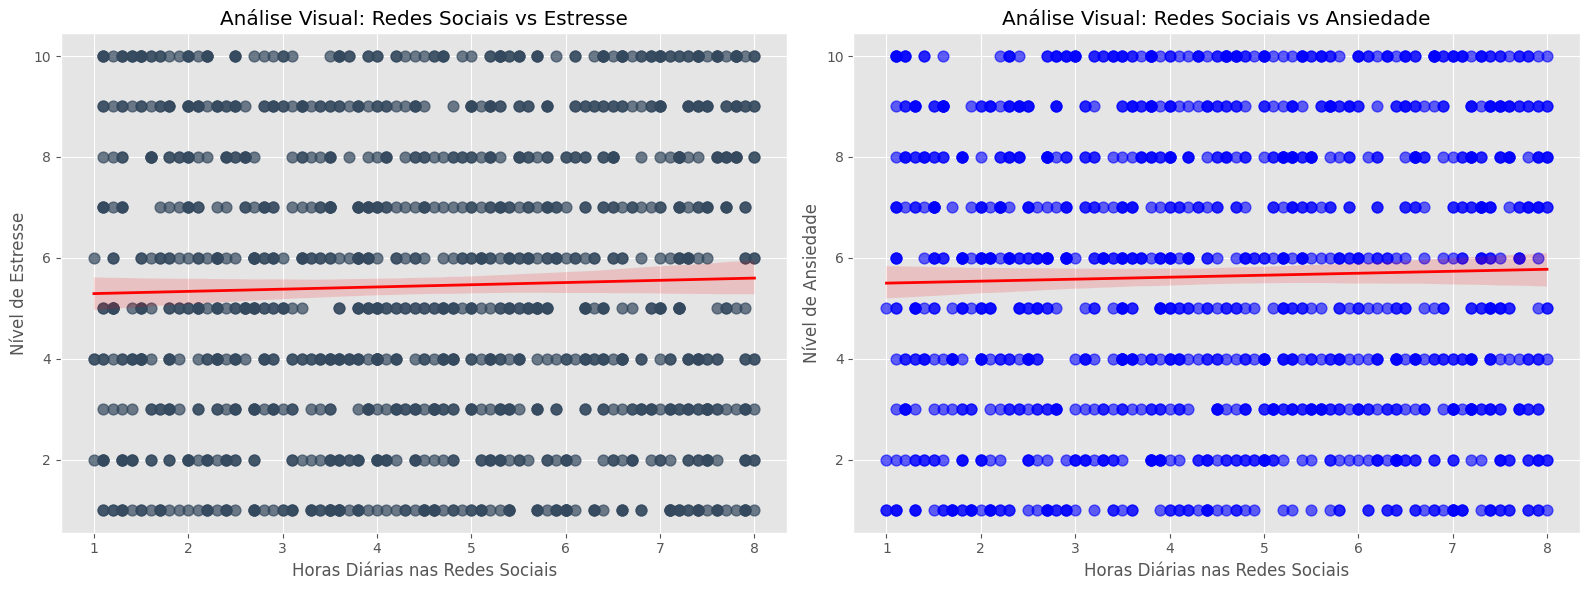

In [ ]:
# Configura o estilo clássico do ggplot
plt.style.use('ggplot')


# O regplot calcula e desenha a linha de tendência
fig, (ax1, ax2) = plt.subplots(figsize=(16, 6), ncols=2)

sns.regplot(data=df, x='daily_social_media_hours', y='stress_level',marker= 'o', scatter_kws={'alpha':0.7, 'color': '#34495E', 's': 60 }, line_kws={'color': 'red', 'linewidth': 2}, ax = ax1)
ax1.set_title('Análise Visual: Redes Sociais vs Estresse')
ax1.set_xlabel('Horas Diárias nas Redes Sociais')
ax1.set_ylabel('Nível de Estresse')


sns.regplot(data=df, x='daily_social_media_hours', y='anxiety_level', scatter_kws={'alpha':0.6, 'color': 'blue', 's': 60}, line_kws={'color': 'red', 'linewidth': 2}, ax = ax2)
ax2.set_title('Análise Visual: Redes Sociais vs Ansiedade')
ax2.set_xlabel('Horas Diárias nas Redes Sociais')
ax2.set_ylabel('Nível de Ansiedade')


plt.tight_layout()
plt.show()

## 📝 Resumo da Análise

> **Conclusão Principal:** Após a análise estatística e visual dos dados, foi verificado que **não existe nenhuma relação direta** entre o número de horas diárias gastas nas redes sociais (`daily_social_media_hours`) e os níveis de estresse (`stress_level`) ou ansiedade (`anxiety_level`) dos participantes.

### 🔍 Evidências Observadas:
* **Dispersão dos Dados:** Indivíduos que passam poucas horas conectados apresentaram notas de estresse e ansiedade tão variados quanto aqueles que passam muitas horas.
* **Fator Preditor:** Os resultados indicam que o tempo bruto de uso da tecnologia **não influencia** essas condições de saúde mental nesta amostra específica.
* **Comportamento das Linhas de Tendência:** Visualmente, as linhas do gráfico de regressão linear apresentaram-se quase que totalmente horizontais (uma pequena inclinação), confirmando que o estresse e a ansiedade não aumentam de forma drástica e nem diminuem conforme o tempo de tela avança.


###**2.** Como a depressão(`depression_label`) afeta os níveis de estresse(`stress_level`) e ansiedade(`anxiety_level`) nos jovens?

Text(0.5, 1.0, 'Análise Visual: Depressão vs Estresse e Ansiedade')

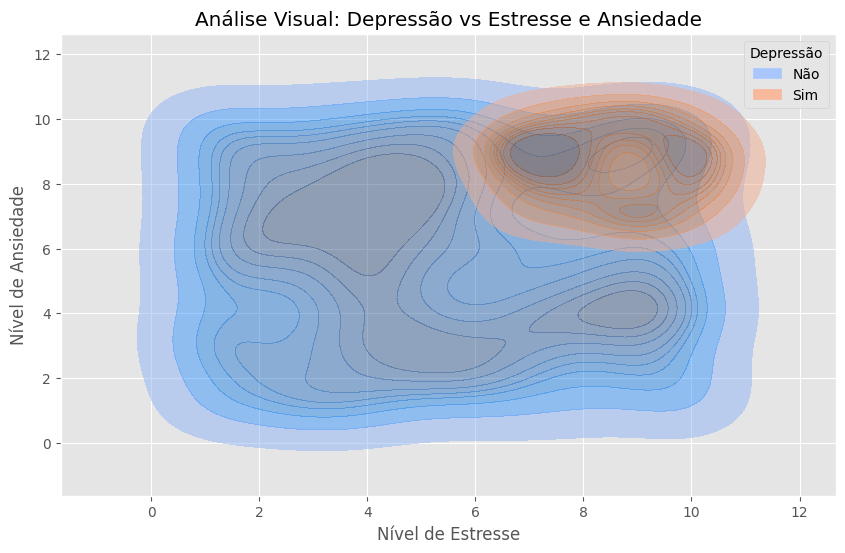

In [ ]:
plt.figure(figsize=(10, 6))

# Construção do gráfico
ax = sns.kdeplot(
    data=df,
    x='stress_level',
    y='anxiety_level',
    hue='depression_label',
    fill=True,
    common_norm=False,
    legend=True,
    palette='coolwarm',
    alpha=0.5,
    thresh=0.05,
    levels=10
)

handles = ax.legend_.legend_handles
ax.legend(handles=handles, labels=['Não', 'Sim'], title='Depressão')


#Renomeando os eixos
plt.xlabel('Nível de Estresse')
plt.ylabel('Nível de Ansiedade')

#Nomeia o título
plt.title('Análise Visual: Depressão vs Estresse e Ansiedade')

## 📝 Resumo da Análise

> **Conclusão Principal:** Após a análise estatística e visual do gráfico, foi verificado que **existe uma forte relação** entre os graus de ansiedade(`anxiety_level`) e estresse(`stress_level`) com a ocorrência de episódios depressivos(`depression_label`).

### 🔍 Evidências Observadas:
* **Dispersão e Concentração dos Dados:** O gráfico de densidade revela diferenças de comportamento nos dois grupos, os indivíduos sem indicativos depressivos estão bem mais disperso no gráfico, enquanto os adolescentes do segundo grupo se concentram em elevados níveis de ansiedade e estresse.
* **Comportamento dos Núcleos de Densidade:** Visualmente, as curvas de nível mostram que o ponto de maior densidade do grupo não depressivo situa-se em patamares mínimos. Já o grupo com depressão apresenta um deslocamento drástico de massa para o quadrante superior direito, confirmando graficamente que a ansiedade e o estresse escalam de forma conjunta e acentuada conforme a condição depressiva se estabelece.


###**3.** Adolescentes com quadros de depressão (`depression_label`) passam mais tempo diariamente nas redes sociais (`daily_social_media_hours`)?

Text(0, 0.5, 'Horas Diárias Gastas nas Redes Sociais')

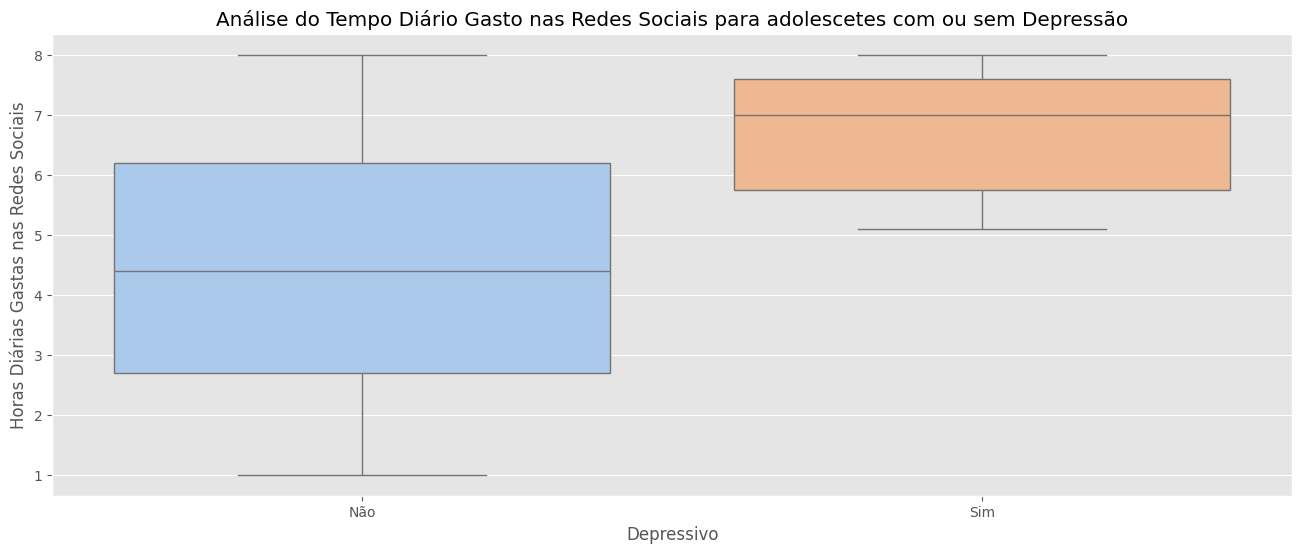

In [ ]:
plt.figure(figsize=(16,6))
plt.title("Análise do Tempo Diário Gasto nas Redes Sociais para adolescetes com ou sem Depressão")

#Construção do gráfico
sns.boxplot(
    data=df,
    x="depression_label",
    y="daily_social_media_hours",
    hue="depression_label",
    palette="pastel",
    legend=False
)
#Renomeia as colunas
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'])

#Renomeia os eixos
plt.xlabel("Depressivo")
plt.ylabel("Horas Diárias Gastas nas Redes Sociais")

## 📝 Resumo da Análise

> **Conclusão Principal:** Após a análise estatística e visual dos "candles", foi verificado que **existe uma forte relação** entre o número de horas diárias gastas nas redes sociais (`daily_social_media_hours`) e a ocorrência de episódios depressivos(`depression_label`).

### 🔍 Evidências Observadas:
* **Deslocamento das medianas:** A linha central do grupo de indíce 0 está posicionada significativamente mais baixa em comparação a do grupo 1, isso indica que o comportamento médio dos dois grupos é marcadamente diferente.
* **Concentração e Afunilamento dos Dados:** O grupo 1 apresenta uma caixa muito mais compacta e concentrada no topo do gráfico. Isso significa que indivíduos com depressão mostram um comportamento mais homogêneo e previsível.
* **Amplitude e Variabilidade:** O grupo 0 é muito mais disperso, cobrindo praticamente toda a escala do gráfico. Isso demonstra que pessoas sem depressão têm rotinas digitais altamente variadas, enquanto o grupo com depressão está fortemente concentrado em altos níveis de uso.

###**4.** O nível de interação social na vida real (`social_interaction_level`) influencia no nível de vício (`addiction_level`) em telas\redes dos adolescentes?

Text(0.5, 0, 'Grau de interação social')

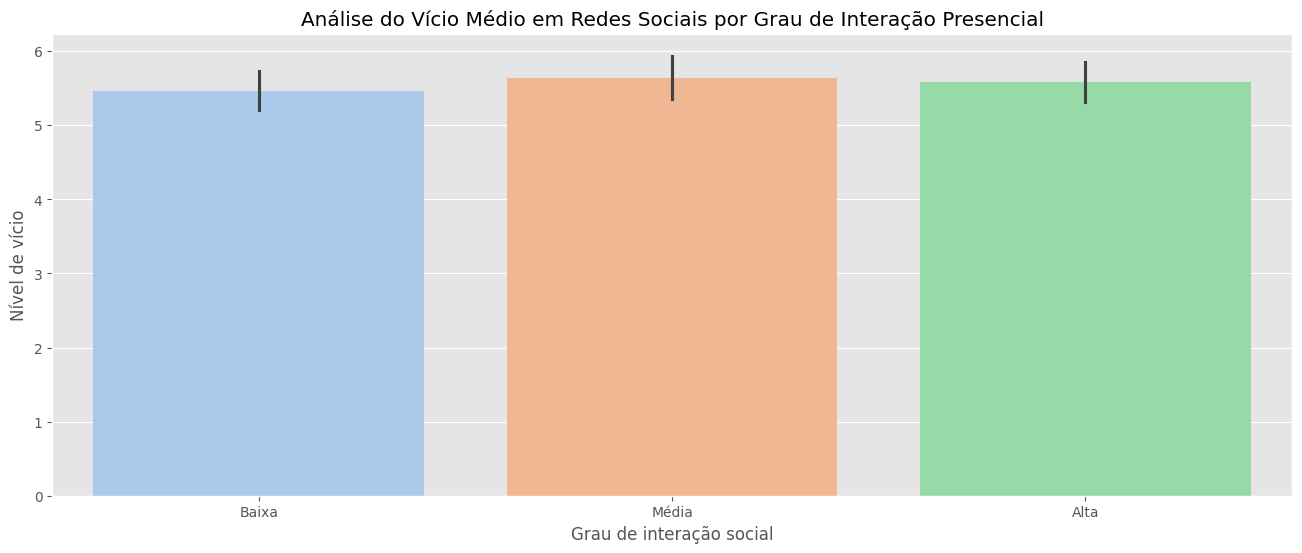

In [ ]:
plt.figure(figsize=(16,6))
plt.title("Análise do Vício Médio em Redes Sociais por Grau de Interação Presencial")

#Ordena as colunas
ordem_desejada = ['low', 'medium', 'high']

#Construção do gráfico
sns.barplot(
    data=df,
    x="social_interaction_level",
    y="addiction_level",
    hue="social_interaction_level",
    palette="pastel",
    order=ordem_desejada,
    hue_order=ordem_desejada,
    legend=False
)
plt.xticks(ticks=[0, 1, 2], labels=['Baixa', 'Média', 'Alta']) #Renomeia cada coluna

#Nomeia os eixos
plt.ylabel("Nível de vício")
plt.xlabel("Grau de interação social")

## 📝 Resumo da Análise

> **Conclusão Principal:** Após a visualização do  gráfico, foi verificado que **não existe nenhuma relação direta** entre o grau de interação social na vida real (`social_interaction_level`) e os níveis de vício nas redes sociais(`addiction_level`) nos adolescentes.

### 🔍 Evidências Observadas:
* **Similaridade entre as barras:** Conforme o observado no comportamento do gráfico, os índices de dependência digital mantiveram-se equivalentes em todas as classes de indivíduos. Essa constância contraria a noção intuitiva de que a dependência em relação as redes é responsável pelo isolamento social.

###**5.** Indivíduos com episódios depressivos(`depression_label`) apresentam menos horas de sono(`sleep_hours`)

Text(0, 0.5, 'Horas de Sono')

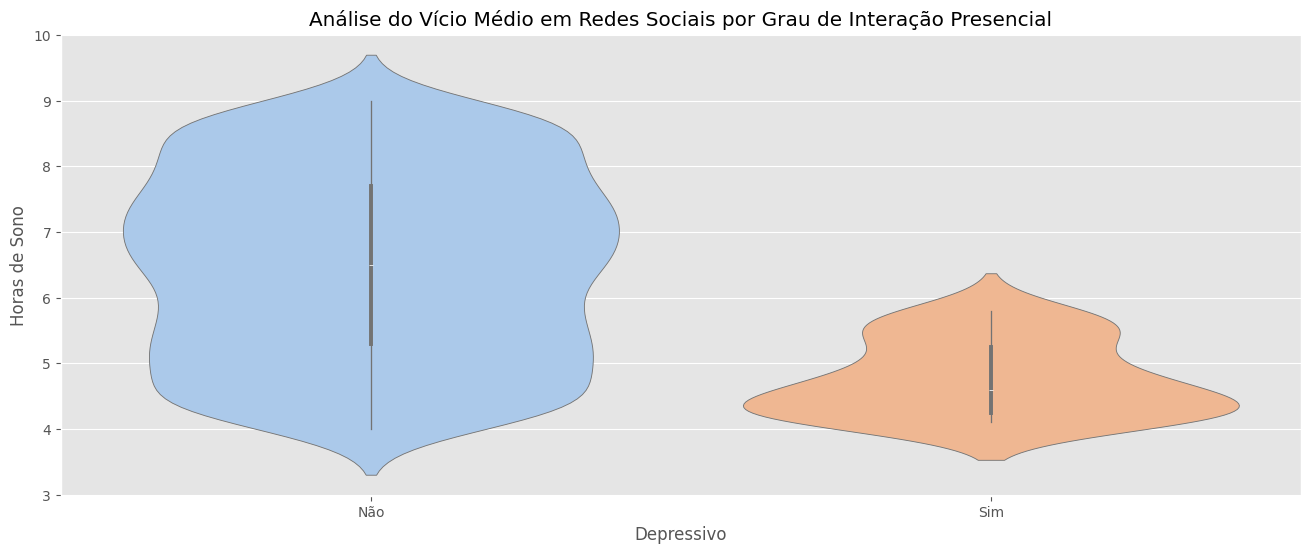

In [ ]:
plt.figure(figsize=(16, 6))
plt.title("Análise do número de horas de sono  em jovens com\sem depressão")

#Construção do gráfico
sns.violinplot(
    x='depression_label',
    y='sleep_hours',
    hue="depression_label",
    palette="pastel",
    legend=False,
    data=df
)
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'])#Renomeia as colunas

#Renomeia as colunas
plt.xlabel("Depressivo")
plt.ylabel("Horas de Sono")

## 📝 Resumo da Análise

> **Conclusão Principal:** Após a análise estatística e visual do gráfico, foi verificado que **existe uma forte relação** entre o número de horas de sono (`sleep_hours`) e a ocorrência de episódios depressivos(`depression_label`).

### 🔍 Evidências Observadas:
* **Comportamento das Medianas:** Visualmente, o ponto central e o "corpo" mais largo do violino laranja (Sim) situam-se em patamares inferiores aos do violino azul (Não). Isso induz a percepção de que indivíduos com indicativos depressivos sofrem uma compressão no tempo total de sono.
* **Dispersão e Distribuição dos Dados:** Indivíduos classificados como não depressivos apresentam uma dispersão de horas de sono muito mais ampla e equilibrada. Em contrapartida, o grupo identificado como depressivo mostra uma distribuição visivelmente achatada e deslocada para baixo.

## **4.** CONSIDERAÇÕES FINAIS

## ✅ Principais resultados:

*   Elevados níveis de estresse e ansidedade podem estar relacionados com casos de depressão;

*   Adolescentes com episódios depressivos tendem a passar mais horas diárias nas redes sociais;

*   Jovens diagnosticados com depressão aparentam dormir menos;

## ❗Limitações do estudo:

*   Limitação geográfica(onde ocorreu o estudo e se para diferentes ambientes os padrões se repetem);

*   Limitação das redes estudadas(apenas duas plataformas foram observadas, como outras plataformas impactariam nos dados);

## ⭐ Aplicação da análise:

*   Aplicação em modelos de aprendizado de máquina para identificar possíveis casos de depressão;
